<a href="https://colab.research.google.com/github/Virvivek007/House_price_Data_Analytics/blob/main/House_Price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 1 Importing Python Module

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset


In [46]:
#load dataset
train_data_path = r"/content/sample_data/california_housing_test.csv"
test_data_path  = r"/content/sample_data/california_housing_train.csv"

df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path )

print("Shape of df_train:",df_train.shape)
print("Shape of df_test:",df_test.shape)

Shape of df_train: (3000, 9)
Shape of df_test: (17000, 9)


In [47]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

# Step 2 — Data Quality Assessment

# Display first 5 Rows

In [48]:
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [49]:
df_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [50]:
df = pd.concat([df_train,df_test])
print("Shape of Integrated Data/ DF: ",df.shape)

Shape of Integrated Data/ DF:  (20000, 9)


In [51]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


# Display Last 5 Rows

In [52]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0
16999,-124.35,40.54,52.0,1820.0,300.0,806.0,270.0,3.0147,94600.0


# Data Information

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20000 non-null  float64
 1   latitude            20000 non-null  float64
 2   housing_median_age  20000 non-null  float64
 3   total_rooms         20000 non-null  float64
 4   total_bedrooms      20000 non-null  float64
 5   population          20000 non-null  float64
 6   households          20000 non-null  float64
 7   median_income       20000 non-null  float64
 8   median_house_value  20000 non-null  float64
dtypes: float64(9)
memory usage: 1.5 MB


In [54]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-119.566172,35.626750,28.627750,2637.051550,537.991800,1425.557650,499.525450,3.872132,207082.716750
std,2.003609,2.136141,12.582229,2176.314757,420.631119,1131.048487,381.729517,1.900356,115557.055856
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1451.000000,296.000000,788.000000,280.000000,2.562500,119800.000000
50%,-118.490000,34.250000,29.000000,2126.000000,434.000000,1166.000000,409.000000,3.536000,179800.000000
75%,-118.000000,37.710000,37.000000,3149.000000,647.000000,1724.000000,604.000000,4.745325,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [55]:
print(f"Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nStatistical Summary:\n{df.describe()}")

Shape: (20000, 9)

Missing Values:
Series([], dtype: int64)

Duplicates: 0

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object

Statistical Summary:
          longitude      latitude  housing_median_age   total_rooms  \
count  20000.000000  20000.000000        20000.000000  20000.000000   
mean    -119.566172     35.626750           28.627750   2637.051550   
std        2.003609      2.136141           12.582229   2176.314757   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1451.000000   
50%     -118.490000     34.250000           29.000000   2126.000000   
75%     -118.000000     37.710000           37.000000   3149.000000   
max     -114.310000     41.950000     

# Step 3 — Data Cleaning & Transformation

In [56]:
# This ensures the changes are properly assigned back to the DataFrame.
num_cols = ['longitude', 'latitude', 'population']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify if any missing values remain in the specified columns
print(f"Missing values after correction:\n{df[num_cols].isnull().sum()}")

Missing values after correction:
longitude     0
latitude      0
population    0
dtype: int64


# Exploratory Data Analysis

In [57]:
import plotly.express as px

df = pd.concat([df_train, df_test])
num_cols = ['longitude', 'latitude', 'population']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="median_house_value",
    size="population",
    color_continuous_scale=px.colors.cyclical.IceFire,
    size_max=15,
    zoom=10,
    title="California Housing Prices"
)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [58]:
print("Columns in df_train:", df_train.columns)
print("Columns in df_test:", df_test.columns)

Columns in df_train: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
Columns in df_test: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [59]:
import plotly.express as px

# Group by housing_median_age and calculate the mean median_house_value
age_vs_value = df.groupby('housing_median_age')['median_house_value'].mean().reset_index()

fig = px.bar(
    age_vs_value,
    x='housing_median_age',
    y='median_house_value',
    title='Median House Value by Housing Median Age',
    labels={'housing_median_age': 'Housing Median Age', 'median_house_value': 'Median House Value'}
)
fig.show()

In [60]:
import plotly.express as px

fig = px.scatter(
    df,
    x='median_income',
    y='median_house_value',
    title='Median House Value vs. Median Income',
    labels={'median_income': 'Median Income', 'median_house_value': 'Median House Value'},
    hover_name='median_house_value' # Display median_house_value on hover
)
fig.show()

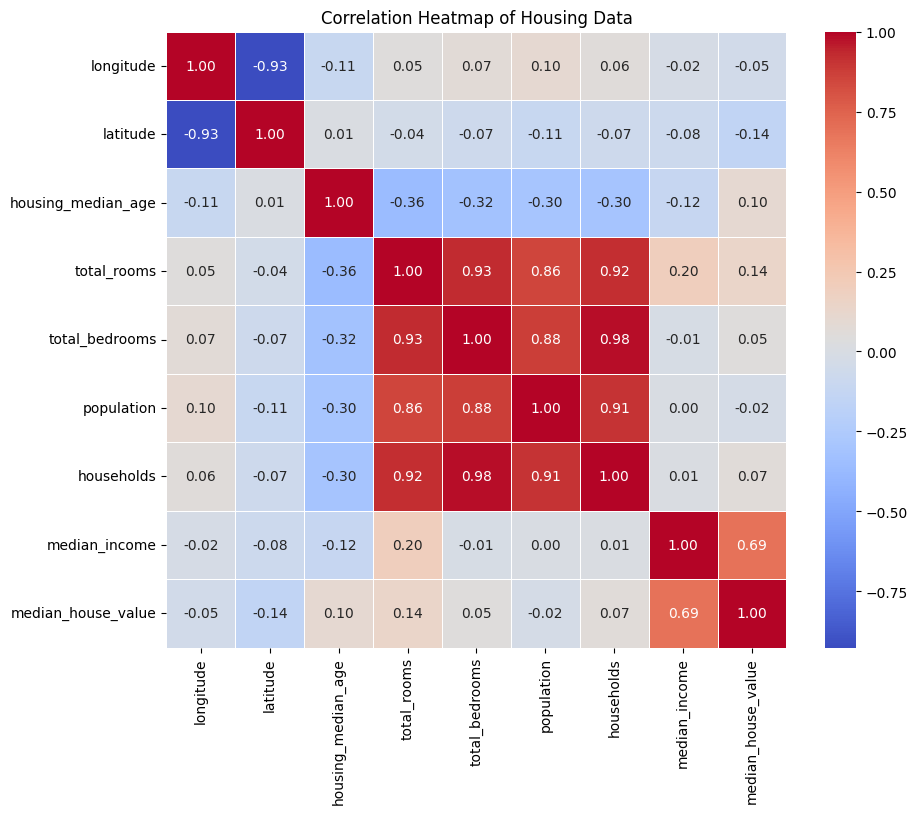

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Housing Data')
plt.show()

### Question 1: How does geographical location, specifically `latitude` and `longitude`, influence the `median_house_value` in this dataset?

**Answer:** Geographical location heavily influences `median_house_value`. Coastal areas, especially in Southern California, show higher values, while inland and northern regions tend to have lower values. These coordinates act as proxies for desirability factors like climate and proximity to amenities.

### Question 2: What is the nature of the relationship between `median_income` and `median_house_value`, and what implications does it have?

**Answer:** There's a strong positive correlation between `median_income` and `median_house_value`. As income rises, house values generally increase. This indicates that higher earning potential or wealthier residents drive up property prices, making `median_income` a crucial predictor for housing models.

### Question 3: Is there a discernible pattern or relationship between `housing_median_age` and `median_house_value`?

**Answer:** The relationship between `housing_median_age` and `median_house_value` is complex and non-linear. While new or very old homes can sometimes fetch higher prices, properties in the middle age range might show slightly lower values. Age alone isn't a direct determinant; other factors like renovation and neighborhood play a role.

### Question 4: Beyond income and age, what significant correlations exist between other features (`total_rooms`, `population`, `households`, `total_bedrooms`) and `median_house_value` as indicated by the heatmap?

**Answer:** `total_rooms`, `total_bedrooms`, `population`, and `households` show weaker direct correlations with `median_house_value` compared to `median_income`. These features often scale with block size rather than directly indicating wealth. However, they are highly correlated with each other, suggesting potential multicollinearity issues if used directly without feature engineering.

### Question 5: What additional insights could be gained by creating new features like `rooms_per_household`, `bedrooms_per_room`, and `population_per_household`?

**Answer:** Deriving ratios like `rooms_per_household`, `bedrooms_per_room`, and `population_per_household` can offer more interpretable insights. These features normalize raw counts, reflecting spaciousness, dwelling type, and density, which often correlate more strongly with `median_house_value` than their raw counterparts.